In [31]:
!pip install timm torchinfo scikit-learn -q

## 0. Download dataset

In [4]:
## Download Vehicle Plate (cropped) dataset
## https://drive.google.com/file/d/1z-hYHm4aeDC8ScJWT9PUczbYJfhqj3Kj
!gdown 1z-hYHm4aeDC8ScJWT9PUczbYJfhqj3Kj
!unzip -q plates.zip

Downloading...
From (original): https://drive.google.com/uc?id=1z-hYHm4aeDC8ScJWT9PUczbYJfhqj3Kj
From (redirected): https://drive.google.com/uc?id=1z-hYHm4aeDC8ScJWT9PUczbYJfhqj3Kj&confirm=t&uuid=f702ed52-a6bb-4e9a-8646-d93d513261c6
To: /content/plates.zip
100% 42.8M/42.8M [00:00<00:00, 54.8MB/s]


## 1. Import libraries

In [32]:
import os
import time
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms
import timm
from sklearn.model_selection import train_test_split

## 2. Read dataset

In [35]:
root_dir = "plates"
labels_path = os.path.join(root_dir, "labels.txt")

img_paths = []
labels = []

with open(labels_path, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line: continue
        parts = line.split(maxsplit=1)
        if len(parts) == 2:
            img_paths.append(parts[0])
            labels.append(parts[1].strip().upper())

print(f"Tổng số ảnh: {len(img_paths)}")
print(f"Ví dụ: {img_paths[0]} → {labels[0]}")

Tổng số ảnh: 4323
Ví dụ: plates/000000.jpg → 51F79512


## 3. Prepare vocabulary

In [36]:
all_chars = "".join(labels)
unique_chars = sorted(list(set(all_chars)))
blank_char = "-"
chars = [blank_char] + unique_chars

vocab_size = len(chars)
char_to_idx = {char: idx for idx, char in enumerate(chars)}
idx_to_char = {idx: char for char, idx in char_to_idx.items()}

max_label_len = max(len(label) for label in labels)
print(f"Kích thước Vocab: {vocab_size} | Độ dài nhãn tối đa: {max_label_len}")

Kích thước Vocab: 33 | Độ dài nhãn tối đa: 10


## 4. Encode / Decode

In [37]:
def encode(label, char_to_idx, max_label_len):
    encoded = torch.tensor([char_to_idx[c] for c in label], dtype=torch.long)
    label_len = torch.tensor(len(encoded), dtype=torch.long)
    padded = F.pad(encoded, (0, max_label_len - len(encoded)), value=0)
    return padded, label_len

def decode(encoded_sequences, idx_to_char, blank_char="-"):
    decoded_sequences = []
    for seq in encoded_sequences:
        decoded = []
        prev_token = None
        for token in seq:
            token_val = token.item()

            if idx_to_char[token_val] == blank_char:
                prev_token = None
                continue

            if token_val != prev_token:
                decoded.append(idx_to_char[token_val])
                prev_token = token_val
        decoded_sequences.append("".join(decoded))
    return decoded_sequences

def decode_label(encoded_sequences, idx_to_char):
    decoded_sequences = []
    for seq in encoded_sequences:
        # Nhãn gốc không có blank CTC xen kẽ, chỉ có padding 0 ở cuối
        decoded_label = [idx_to_char[token.item()] for token in seq if token.item() != 0]
        decoded_sequences.append("".join(decoded_label))
    return decoded_sequences

## 5. Create data preprocessing function

In [38]:
data_transforms = {
    "train": transforms.Compose([
        transforms.Resize((100, 420)),
        transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4),
        transforms.Grayscale(num_output_channels=1),
        transforms.GaussianBlur(3),
        transforms.RandomAffine(degrees=3, shear=3),
        transforms.RandomPerspective(distortion_scale=0.3, p=0.6),
        transforms.RandomRotation(degrees=4),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,)),
    ]),
    "val": transforms.Compose([
        transforms.Resize((100, 420)),
        transforms.Grayscale(num_output_channels=1),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,)),
    ]),
}

## 6. Train, val, test split

In [39]:
seed = 0
val_size = 0.1
test_size = 0.1
is_shuffle = True

X_train, X_val, y_train, y_val = train_test_split(
    img_paths,
    labels,
    test_size=val_size,
    random_state=seed,
    shuffle=is_shuffle,
)

X_train, X_test, y_train, y_test = train_test_split(
    X_train,
    y_train,
    test_size=test_size,
    random_state=seed,
    shuffle=is_shuffle,
)

## 7. Create pytorch dataset

In [40]:
class OCRDataset(Dataset):
    def __init__(self, X, y, char_to_idx, max_label_len, transform=None):
        self.img_paths = X
        self.labels = y
        self.char_to_idx = char_to_idx
        self.max_label_len = max_label_len
        self.transform = transform

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img = Image.open(self.img_paths[idx]).convert("RGB")
        label = self.labels[idx]

        if self.transform:
            img = self.transform(img)

        encoded_label, label_len = encode(label, self.char_to_idx, self.max_label_len)
        return img, encoded_label, label_len

## 8. Create dataloader

In [41]:
train_dataset = OCRDataset(
    X_train,
    y_train,
    char_to_idx=char_to_idx,
    max_label_len=max_label_len,
    transform=data_transforms["train"],
)
val_dataset = OCRDataset(
    X_val,
    y_val,
    char_to_idx=char_to_idx,
    max_label_len=max_label_len,
    transform=data_transforms["val"],
)
test_dataset = OCRDataset(
    X_test,
    y_test,
    char_to_idx=char_to_idx,
    max_label_len=max_label_len,
    transform=data_transforms["val"],
)

In [42]:
print(
    f"Train dataset: {len(train_dataset)}",
    f"Val dataset: {len(val_dataset)}",
    f"Test dataset: {len(test_dataset)}",
    sep="\n",
)

Train dataset: 3501
Val dataset: 433
Test dataset: 389


In [43]:
train_batch_size = 64
test_batch_size = 64 * 2

train_loader = DataLoader(
    train_dataset,
    batch_size=train_batch_size,
    shuffle=True,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=test_batch_size,
    shuffle=False,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=test_batch_size,
    shuffle=False,
)

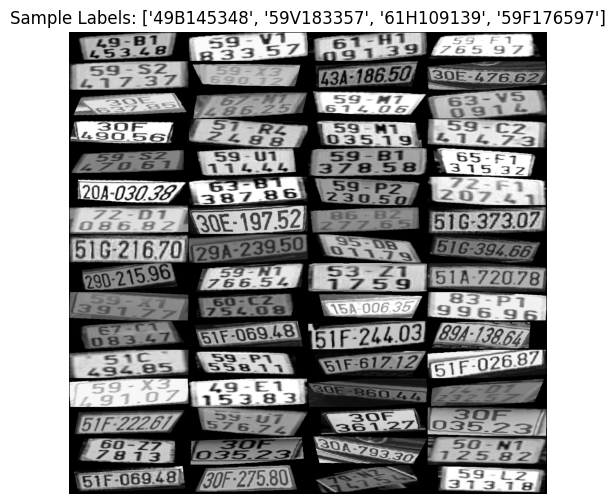

In [44]:
def show_batch(imgs, labels):
    labels_text = decode_label(labels, idx_to_char)
    grid = torchvision.utils.make_grid(imgs, nrow=4, normalize=True)
    plt.figure(figsize=(12, 6))
    plt.imshow(np.transpose(grid.cpu(), (1, 2, 0)))
    plt.title(f"Sample Labels: {labels_text[:4]}")
    plt.axis("off")
    plt.show()

train_features, train_labels, train_lengths = next(iter(train_loader))
show_batch(train_features, train_labels)

## 9. Create model

In [45]:
class CRNN(nn.Module):
    def __init__(
        self, vocab_size, hidden_size, n_layers, dropout=0.2, unfreeze_layers=3
    ):
        super(CRNN, self).__init__()

        backbone = timm.create_model("resnet34", in_chans=1, pretrained=True)
        modules = list(backbone.children())[:-2]
        modules.append(nn.AdaptiveAvgPool2d((1, None)))
        self.backbone = nn.Sequential(*modules)

        # Unfreeze the last few layers
        for parameter in self.backbone[-unfreeze_layers:].parameters():
            parameter.requires_grad = True

        self.mapSeq = nn.Sequential(
            nn.Linear(512, 512), nn.ReLU(), nn.Dropout(dropout)
        )

        self.gru = nn.GRU(
            512,
            hidden_size,
            n_layers,
            bidirectional=True,
            batch_first=True,
            dropout=dropout if n_layers > 1 else 0,
        )
        self.layer_norm = nn.LayerNorm(hidden_size * 2)

        self.out = nn.Sequential(
            nn.Linear(hidden_size * 2, vocab_size), nn.LogSoftmax(dim=2)
        )

    @torch.autocast(device_type="cuda")
    def forward(self, x):
        x = self.backbone(x)
        x = x.permute(0, 3, 1, 2)
        x = x.view(x.size(0), x.size(1), -1)  # Flatten the feature map
        x = self.mapSeq(x)
        x, _ = self.gru(x)
        x = self.layer_norm(x)
        x = self.out(x)
        x = x.permute(1, 0, 2)  # Based on CTC

        return x

In [47]:
hidden_size = 256
n_layers = 3
dropout_prob = 0.2
unfreeze_layers = 3
device = "cuda" if torch.cuda.is_available() else "cpu"

model = CRNN(
    vocab_size=vocab_size,
    hidden_size=hidden_size,
    n_layers=n_layers,
    dropout=dropout_prob,
    unfreeze_layers=unfreeze_layers,
).to(device)

In [48]:
model.eval()

dummy_tensor = torch.rand((64, 1, 100, 420)).to(device)

with torch.no_grad():
    output = model(dummy_tensor)

print("Output shape:", output.shape)

Output shape: torch.Size([14, 64, 33])


## 10. Training

In [49]:
def evaluate(model, dataloader, criterion, device):
    model.eval()
    losses = []
    with torch.no_grad():
        for idx, (inputs, labels, labels_len) in enumerate(dataloader):
            inputs = inputs.to(device)
            labels = labels.to(device)
            labels_len = labels_len.to(device)

            outputs = model(inputs)
            logits_lens = torch.full(
                size=(outputs.size(1),), fill_value=outputs.size(0), dtype=torch.long
            ).to(device)

            # Correctly prepare targets for CTCLoss
            targets = []
            for i in range(labels.size(0)): # Iterate through batch
                targets.append(labels[i, :labels_len[i]]) # Take only non-padded part
            targets = torch.cat(targets).cpu()

            loss = criterion(outputs, targets, logits_lens.cpu(), labels_len.cpu())
            losses.append(loss.item())

    loss = sum(losses) / len(losses)

    return loss

In [50]:
def fit(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    device,
    epochs,
    max_grad_norm=2,
):
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        start = time.time()

        batch_train_losses = []

        model.train()
        for idx, (inputs, labels, labels_len) in enumerate(train_loader):
            inputs = inputs.to(device)
            labels = labels.to(device)
            labels_len = labels_len.to(device)

            optimizer.zero_grad()

            outputs = model(inputs)

            logits_lens = torch.full(
                size=(outputs.size(1),),
                fill_value=outputs.size(0),
                dtype=torch.long,
            ).to(device)

            # Correctly prepare targets for CTCLoss
            targets = []
            for i in range(labels.size(0)): # Iterate through batch
                targets.append(labels[i, :labels_len[i]]) # Take only non-padded part
            targets = torch.cat(targets).cpu()

            loss = criterion(outputs, targets, logits_lens.cpu(), labels_len.cpu())

            loss.backward()

            # Gradient clipping with a configurable max norm
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)

            optimizer.step()

            batch_train_losses.append(loss.item())

        train_loss = sum(batch_train_losses) / len(batch_train_losses)
        train_losses.append(train_loss)

        val_loss = evaluate(model, val_loader, criterion, device)
        val_losses.append(val_loss)

        print(
            f"EPOCH {epoch + 1}:\tTrain loss: {train_loss:.4f}\tVal loss: {val_loss:.4f}\t\t Time: {time.time() - start:.2f} seconds"
        )

        scheduler.step()

    return train_losses, val_losses

In [52]:
epochs = 100
lr = 1e-3
weight_decay = 1e-5
scheduler_step_size = epochs * 0.5

criterion = nn.CTCLoss(
    blank=char_to_idx[blank_char], # This will now be 0
    zero_infinity=True,
    reduction="mean",
)
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=lr,
    weight_decay=weight_decay,
)
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer, step_size=scheduler_step_size, gamma=0.1
)

In [53]:
print("Starting training...")
train_losses, val_losses = fit(
    model, train_loader, val_loader, criterion, optimizer, scheduler, device, epochs
)

Starting training...
EPOCH 1:	Train loss: 2.7859	Val loss: 2.3517		 Time: 32.61 seconds
EPOCH 2:	Train loss: 2.0414	Val loss: 1.7907		 Time: 36.27 seconds
EPOCH 3:	Train loss: 1.3803	Val loss: 1.0645		 Time: 31.02 seconds
EPOCH 4:	Train loss: 0.8535	Val loss: 0.7019		 Time: 33.32 seconds
EPOCH 5:	Train loss: 0.6239	Val loss: 0.5953		 Time: 29.66 seconds
EPOCH 6:	Train loss: 0.5526	Val loss: 0.5919		 Time: 29.70 seconds
EPOCH 7:	Train loss: 0.4990	Val loss: 0.5806		 Time: 30.81 seconds
EPOCH 8:	Train loss: 0.4574	Val loss: 0.4690		 Time: 29.89 seconds
EPOCH 9:	Train loss: 0.4235	Val loss: 0.4561		 Time: 29.99 seconds
EPOCH 10:	Train loss: 0.3931	Val loss: 0.4408		 Time: 29.39 seconds
EPOCH 11:	Train loss: 0.3745	Val loss: 0.4019		 Time: 29.59 seconds
EPOCH 12:	Train loss: 0.3409	Val loss: 0.3967		 Time: 30.21 seconds
EPOCH 13:	Train loss: 0.3289	Val loss: 0.4244		 Time: 29.24 seconds
EPOCH 14:	Train loss: 0.3000	Val loss: 0.3842		 Time: 29.70 seconds
EPOCH 15:	Train loss: 0.2745	Val los

## 11. Evaluation

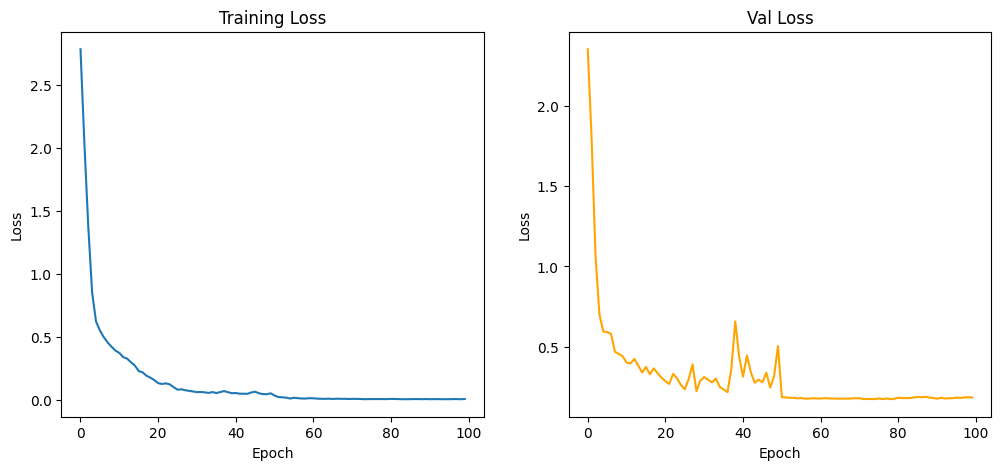

In [54]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(train_losses)
ax[0].set_title("Training Loss")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[1].plot(val_losses, color="orange")
ax[1].set_title("Val Loss")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Loss")
plt.show()

In [55]:
val_loss = evaluate(model, val_loader, criterion, device)
test_loss = evaluate(model, test_loader, criterion, device)

print("Evaluation on val/test dataset")
print("Val loss: ", val_loss)
print("Test loss: ", test_loss)

Evaluation on val/test dataset
Val loss:  0.18511539697647095
Test loss:  0.16399209201335907


## 12. Calculate Metrics

In [56]:
def levenshtein_distance(s1, s2):
    if len(s1) < len(s2): return levenshtein_distance(s2, s1)
    if len(s2) == 0: return len(s1)
    previous_row = range(len(s2) + 1)
    for i, c1 in enumerate(s1):
        current_row = [i + 1]
        for j, c2 in enumerate(s2):
            insertions, deletions, substitutions = previous_row[j + 1] + 1, current_row[j] + 1, previous_row[j] + (c1 != c2)
            current_row.append(min(insertions, deletions, substitutions))
        previous_row = current_row
    return previous_row[-1]

def calculate_metrics(model, dataloader, device, idx_to_char):
    model.eval()
    correct_complete, total_samples, total_char_distance, total_chars = 0, 0, 0, 0
    all_preds, all_targets = [], []

    with torch.no_grad():
        for inputs, labels, labels_len in dataloader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            preds = outputs.permute(1, 0, 2).argmax(2)

            pred_strings = decode(preds, idx_to_char)
            target_strings = decode_label(labels, idx_to_char)

            for p, t in zip(pred_strings, target_strings):
                total_samples += 1
                total_chars += len(t)
                if p == t: correct_complete += 1
                total_char_distance += levenshtein_distance(p, t)
                all_preds.append(p)
                all_targets.append(t)

    accuracy = (correct_complete / total_samples) * 100
    cer = (total_char_distance / total_chars) * 100

    print(f"\n--- BÁO CÁO KẾT QUẢ ĐÁNH GIÁ (TEST SET) ---")
    print(f"Tổng số mẫu test : {total_samples}")
    print(f"Số biển đúng 100%: {correct_complete}")
    print(f"Độ chính xác tuyệt đối (Accuracy): {accuracy:.2f}%")
    print(f"Tỷ lệ lỗi ký tự (CER): {cer:.2f}%")

    print(f"\nChi tiết (Prediction vs Truth):")
    for i in range(min(10, len(all_preds))):
        match_status = "✅" if all_preds[i] == all_targets[i] else "❌"
        print(f"{match_status} P: {all_preds[i]:<10} | T: {all_targets[i]}")

In [59]:
# Giả sử load model đã train trước khi đánh giá:
# model.load_state_dict(torch.load("ocr_crnn.pt", map_location=device))
calculate_metrics(model, test_loader, device, idx_to_char)


--- BÁO CÁO KẾT QUẢ ĐÁNH GIÁ (TEST SET) ---
Tổng số mẫu test : 389
Số biển đúng 100%: 317
Độ chính xác tuyệt đối (Accuracy): 81.49%
Tỷ lệ lỗi ký tự (CER): 2.60%

Chi tiết (Prediction vs Truth):
❌ P: 52T35969   | T: 52Y35969
✅ P: 51A72110   | T: 51A72110
✅ P: 30M4253    | T: 30M4253
❌ P: 30V45882   | T: 30N45882
✅ P: 54L69606   | T: 54L69606
✅ P: 29A60986   | T: 29A60986
✅ P: 59G115255  | T: 59G115255
✅ P: 50LD04411  | T: 50LD04411
✅ P: 59S201079  | T: 59S201079
❌ P: 49E108660  | T: 49F108660


## 12. Make Predictions & Visualize

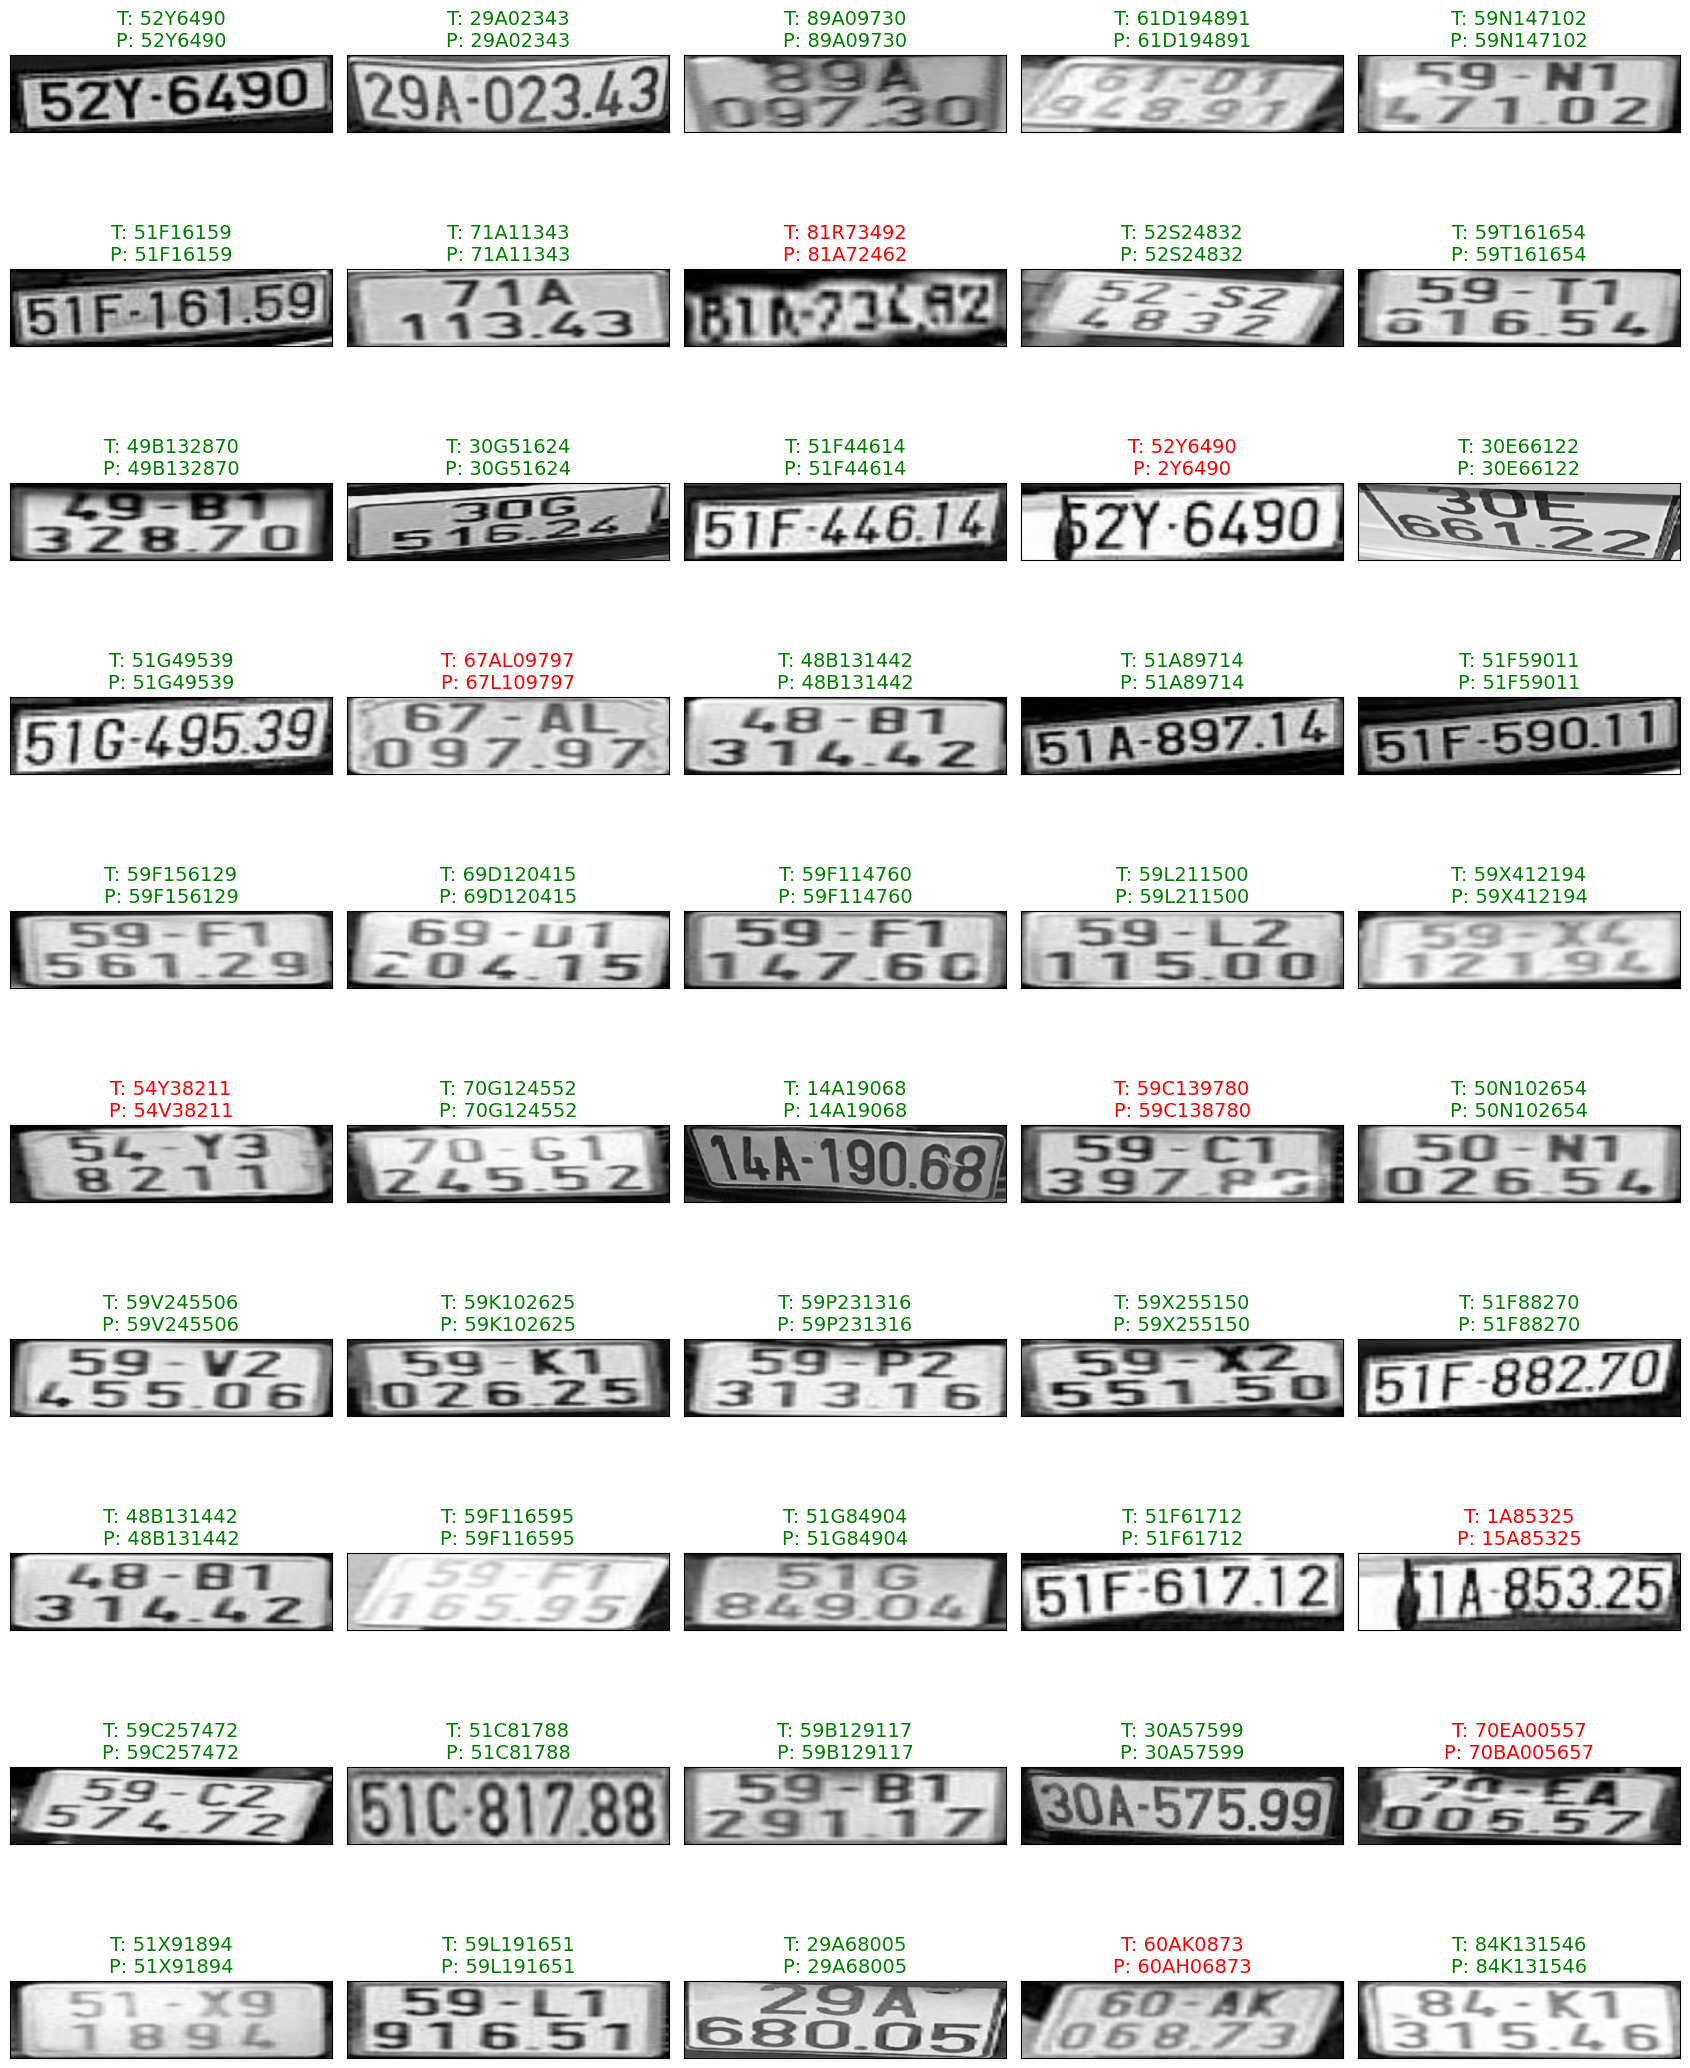

In [57]:
sample_result = []
model.eval()

for i in range(50):
    idx = np.random.randint(len(test_dataset))
    img, label_encoded, label_len = test_dataset[idx]

    img_tensor = img.unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(img_tensor)
        pred_idx = logits.permute(1, 0, 2).argmax(2)
        pred_text = decode(pred_idx, idx_to_char)[0]

    truth_text = decode_label([label_encoded], idx_to_char)[0]
    sample_result.append((img, truth_text, pred_text))

fig = plt.figure(figsize=(17, 22))
for i in range(50):
    ax = fig.add_subplot(10, 5, i + 1, xticks=[], yticks=[])
    img, label, pred_text = sample_result[i]

    img_display = img.permute(1, 2, 0).cpu().numpy()
    ax.imshow(img_display, cmap="gray")

    color = "green" if label == pred_text else "red"
    ax.set_title(f"T: {label}\nP: {pred_text}", color=color, fontsize=14)

plt.tight_layout()
plt.show()

## 13. Save model

In [58]:
save_model_path = "ocr_crnn.pt"
torch.save(model.state_dict(), save_model_path)
print(f"Model saved to {save_model_path}")

Model saved to ocr_crnn.pt
